# Data Analysis Project
**Yuki Matsushima**

## Table of Content
**Introduction**

**Setup and Imports**

**1. Aggregate Inflation in Denmark** \
    1.1 Basics \
    1.2 Instataneous Inflation Analysis \
    1.3 Core Inflation \
    1.4 Disggregated Inflation in Denmark 

**2. International Comparison** \
    2.1 CPI vs HICP \
    2.2 Across countries

**3. Extension Analysis** \
    3.1 Inflation Volatility Across Countries

## Introduction
Inflation has been one of the most defining economic phenomena of the early 2020s. Following the COVID-19 pandemic and the global supply chain disruptions that came with it, prices in many countries surged to levels not seen in decades. Denmark, like most advanced economies, experienced a noticeable rise in consumer prices beginning in 2021 as demand recovered faster than supply and as imported prices increased due to supply bottlenecks and transportation delays. 
This project investigates how inflation in Denmark evolved during and after the pandemic, with a specific focus on identifying when the post-pandemic inflation surge ended and which factors contributed most to it. Understanding these dynamics is important because inflation directly affects household purchasing power, wage negotiations, and the formulation of monetary policy. Examining Denmark—a small, open, and stable economy—also provides insights into how external shocks transmit to domestic prices.

## Setup and Import
This section loads all required packages and prepares the development environment.
- `%load_ext autoreload` and `%autoreload 2` automatically reload Python modules after edits,  
  ensuring the notebook always runs the latest code changes.
- **pandas, numpy, matplotlib, seaborn** – used for data manipulation, analysis, and visualization.  
- **requests** – connects to external APIs such as Statistics Denmark (StatBank).  
- **fredapi** – allows access to the U.S. Federal Reserve’s FRED database for international inflation data later in the project.

The versions of key libraries are printed for reproducibility.

In [32]:
# Enable autoreload for development
%load_ext autoreload
%autoreload 2

# Standard imports
!pip install pandas requests --quiet

import os, io, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# API imports
import requests
from fredapi import Fred

print("Setup complete!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup complete!
Pandas version: 2.2.3
NumPy version: 2.1.3
Matplotlib version: 3.10.0


## 1. Aggregate Inflation Analysis
This section examines Denmark’s overall inflation trends using the national Consumer Price Index (CPI) from Statistics Denmark’s PRIS113 dataset.  
The analysis aims to understand how price levels evolved after 2015, identify when the post-pandemic inflation surge peaked, and determine when inflation returned toward its long-run average.  
To do this, the section proceeds in three steps:  
- Download and clean the CPI data.  
- Calculate both month-to-month and 12-month inflation rates.  
- Visualize the results to interpret key turning points in Danish inflation.

**Research Question: When did the post-pandemic inflation surge in Denmark end**

#### Data Download and Cleaning (PRIS113)
In this part, Danish CPI data are retrieved directly from the official Statistics Denmark API (StatBank) using the PRIS113 table, which records monthly consumer price indices indexed to 100 in 2020.  
A custom function, `load_pris113()`, connects to the API and automatically switches between GET and POST requests to ensure a complete dataset.  
After downloading, the script standardizes column names, converts dates into a usable time-series format, filters observations from 2015 onward, and confirms all CPI values are numeric.  
The final dataset contains two columns — *date* and *cpi* — which will be used to calculate inflation rates in the next step.

In [33]:
def load_pris113(start="1980M01", end=None, lang="en"):
    """
    Robust loader for Danish CPI (PRIS113, TYPE=INDEKS).
    Tries GET with a time range; on 400 falls back to POST with TID='*' and filters in Python.
    Returns columns: ['date','cpi'].
    """
    import os, io, requests, pandas as pd

    # API key
    api_key = os.getenv("DST_API_KEY")
    headers = {"Authorization": f"Bearer {api_key}"} if api_key else {}

    # Helper: parse YYYYMm strings -> pandas Timestamp
    def _to_ts(s):
        return pd.to_datetime(s, format="%YM%m")

    start_ts = _to_ts(start)
    end_ts   = _to_ts(end) if end else None

    
    url_post = "https://api.statbank.dk/v1/data"
    body = {
        "lang": lang,
        "table": "PRIS113",
        "format": "CSV",
        "variables": [
            {"code": "TYPE", "values": ["INDEKS"]},
            {"code": "TID",  "values": ["*"]}  # all periods, we'll filter below
        ]
    }
    r = requests.post(url_post, json=body, headers=headers, timeout=90)
    r.raise_for_status()
    raw_csv = r.text

    # StatBank CSVs are semicolon-separated
    import pandas as pd, io
    df = pd.read_csv(io.StringIO(raw_csv), sep=";")

    # Standardize columns
    # (TYPE may appear as a label column; we only need time+value)
    rename_map = {"TID": "date", "INDHOLD": "cpi"}
    df = df.rename(columns=rename_map)
    # Convert to proper datetime
    df["date"] = pd.to_datetime(df["date"], format="%YM%m", errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date")

    # Filter to requested window
    mask = df["date"] >= start_ts
    if end_ts is not None:
        mask &= df["date"] <= end_ts
    df = df.loc[mask, ["date", "cpi"]].reset_index(drop=True)

    # Ensure numeric CPI
    df["cpi"] = pd.to_numeric(df["cpi"], errors="coerce")
    return df

In [34]:
df_pris113 = load_pris113(start="2015M01")
df_pris113.head(), df_pris113.tail(), df_pris113.shape

(        date    cpi
 0 2015-01-01   98.8
 1 2015-02-01   99.8
 2 2015-03-01  100.2
 3 2015-04-01  100.3
 4 2015-05-01  100.4,
           date    cpi
 127 2025-08-01  121.7
 128 2025-09-01  121.6
 129 2025-10-01  122.1
 130 2025-11-01  121.7
 131 2025-12-01  121.2,
 (132, 2))

In [35]:
# Rebase CPI so that 2020 average = 100
df_pris113["cpi_raw"] = df_pris113["cpi"]  # keep original (2015=100)

base_2020 = df_pris113.loc[df_pris113["date"].dt.year == 2020, "cpi_raw"].mean()
df_pris113["cpi"] = (df_pris113["cpi_raw"] / base_2020) * 100

In [36]:
# Rebase to 2020 check
df_pris113.loc[df_pris113["date"].dt.year == 2020, "cpi"].mean()

np.float64(99.99999999999999)

### 1.1 Basics
Here, the cleaned CPI series is transformed into measures of inflation that capture both short-term and annual price changes.  
The month-to-month inflation rate ($\pi_t$) shows immediate price movements, while the 12-month rate ($\pi_{12,t}$) compares prices to the same month one year earlier, providing a more stable long-term view.  
Because the 12-month change requires a full year of data for comparison, the first valid observation appears in January 2016.  
These new inflation measures create the foundation for understanding the timing and magnitude of Denmark’s inflation surge.

In [37]:
# 1) Compute month-to-month inflation (% change)
df_pris113["infl_mom"] = df_pris113["cpi"].pct_change() * 100

# 2) Compute 12-month inflation (% change vs. 12 months earlier)
df_pris113["infl_12m"] = df_pris113["cpi"].pct_change(12) * 100

# drop first NaN rows created by pct_change
df_pris113 = df_pris113.dropna().reset_index(drop=True)

df_pris113.head()

,date,cpi,cpi_raw,infl_mom,infl_12m
0,2016-01-01,96.100548,99.4,-0.400802,0.607287
1,2016-02-01,96.777312,100.1,0.704225,0.300601
2,2016-03-01,96.873993,100.2,0.099900,0.000000
3,2016-04-01,96.970674,100.3,0.099800,0.000000
4,2016-05-01,97.164035,100.5,0.199402,0.099602


#### Visualization and Interpretation
This part focuses on visualizing the evolution of Denmark’s price levels and inflation rates using the processed CPI data.  
Three main plots are created:
- The first shows the Consumer Price Index (CPI) from 2015 to 2025, illustrating how the overall price level changed over time.  
- The month-to-month inflation rate, capturing short-run price movements from one month to the next.
- The second displays the 12-month inflation rate, highlighting short-term fluctuations and longer-term trends in price growth.  

To support the visual analysis, simple calculations are included to identify the month when inflation reached its highest point and to print the most recent inflation value.  
These summaries provide clear reference points that complement the figures and set up the discussion in the following interpretation section.

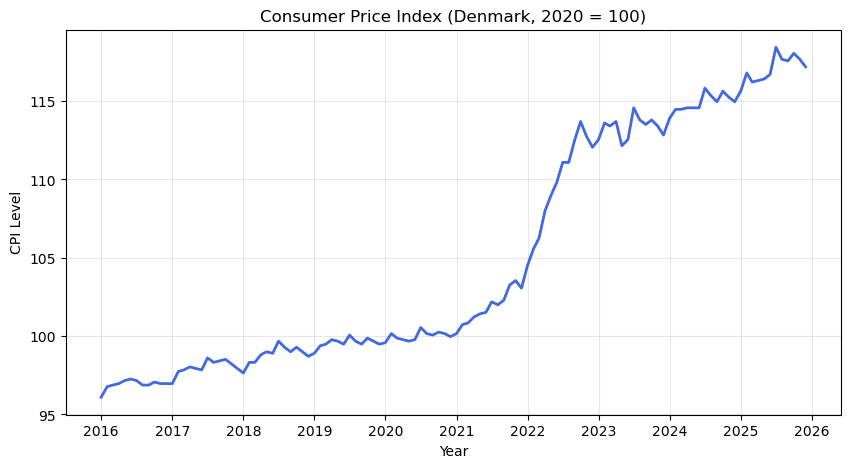

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_pris113["date"], df_pris113["cpi"], color="royalblue", lw=2)
plt.title("Consumer Price Index (Denmark, 2020 = 100)")
plt.xlabel("Year")
plt.ylabel("CPI Level")
plt.grid(alpha=0.3)
plt.show()

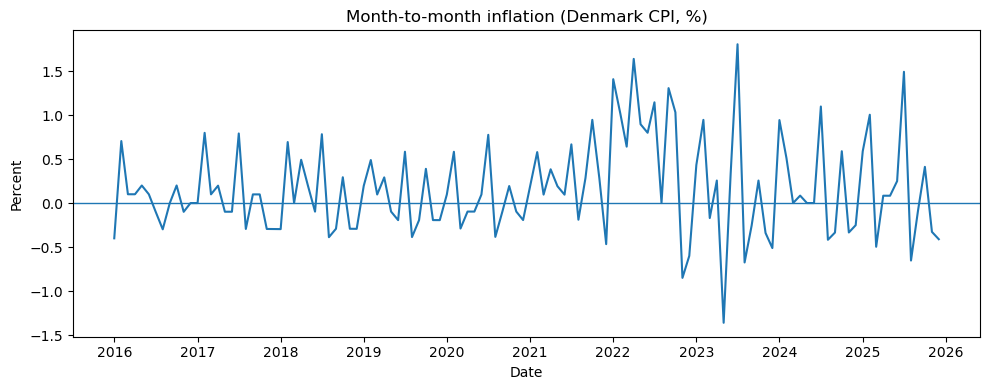

In [39]:
plt.figure(figsize=(10,4))
plt.plot(df_pris113["date"], df_pris113["infl_mom"])
plt.axhline(0, linewidth=1)
plt.title("Month-to-month inflation (Denmark CPI, %)")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.tight_layout()

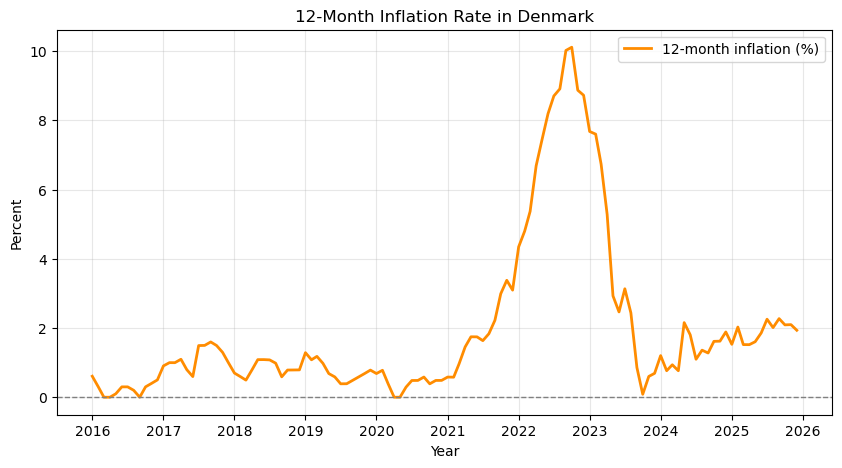

In [40]:
plt.figure(figsize=(10,5))
plt.plot(df_pris113["date"], df_pris113["infl_12m"], color="darkorange", lw=2, label="12-month inflation (%)")
plt.axhline(0, color="gray", ls="--", lw=1)
plt.title("12-Month Inflation Rate in Denmark")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [41]:
peak_row = df_pris113.loc[df_pris113["infl_12m"].idxmax()]
print(f"Inflation peaked at {peak_row['infl_12m']:.2f}% in {peak_row['date'].strftime('%B %Y')}")

latest_row = df_pris113.iloc[-1]
print(f"Latest inflation ({latest_row['date'].strftime('%B %Y')}): {latest_row['infl_12m']:.2f}%")

Inflation peaked at 10.11% in October 2022
Latest inflation (December 2025): 1.93%


#### Interpretation
Denmark’s Consumer Price Index (CPI) remained relatively stable throughout the 2010s, consistent with low and moderate inflation before the pandemic. After 2020, inflation accelerated sharply, with year-over-year inflation peaking at 10.11 percent in October 2022. This spike aligns with the post-pandemic reopening of the economy, global supply-chain bottlenecks, and the energy-price shock associated with Russia’s invasion of Ukraine.

Inflation then declined substantially, reaching 2.27 percent in September 2025, which is closer to pre-pandemic levels. Overall, the data suggest the pandemic-era inflation surge largely ended between late 2022 and early 2023 as supply conditions improved and energy prices stabilized.

### 1.2 Instantaneous Inflation Analysis
Instantaneous inflation rate is defined as: 
> $\pi^{12,\alpha}_t=(\Pi^{11}_{k=0}(1+\pi_{t-k})^{K(k,\alpha)})-1$ \
> $\kappa(k,\alpha)=\frac{(T-k)^\alpha}{\Sigma (T-k)^\alpha}T$

This section builds a instant annual inflation indicator that puts more weight on the most recent months. Unlike standard 12 month inflation (which treats each of the last 12 months equally), instantaneous inflation lets us emphasize fresh price movements via a tuning parameter $\alpha$. This is useful for timing turning points, for example, detecting when inflation starts easing, without waiting for the full year cycle effect to show up.

In [42]:
# Monthly inflation in decimal (not %) for instantaneous formula
if "pi_t" not in df_pris113.columns:
    df_pris113["pi_t"] = df_pris113["cpi"].pct_change()

#### Define Weight Function
We construct the weighting scheme $ \kappa(k,\alpha)$ over the past 12 months, where higher $\alpha$ shifts weight toward the most recent observations.
- $\alpha = 0$: equal weights → identical to standard 12-month inflation.
- $\alpha > 0$: recency-weighted → more responsive to current conditions.
The function returns weights that sum to 1, making the resulting measure directly comparable across $\alpha$.

In [43]:
def kappa_weights(alpha: int, n: int = 12) -> np.ndarray:
    """
    Return weights κ(k, α) for k = 0..n-1 
    We use w_k ∝ (n - k)**α, and scale so that average weight is 1 (sum of weights = n).
    This implies when α = 0, all weights are exactly 1.
    """
    k = np.arange(n)  # 0..n-1 (0 = current month)
    w = (n - k) ** alpha
    w = w / w.sum()
    w = w * n
    return w

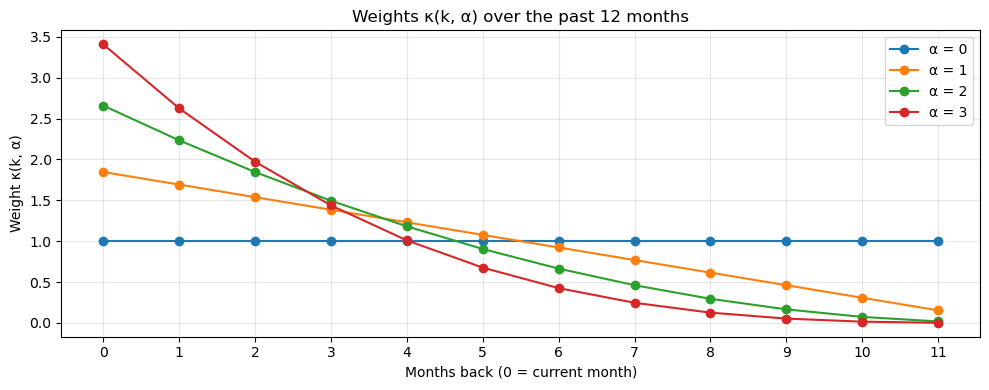

In [44]:
# Plot κ(k, α) weights for α = 0..3
k = np.arange(12)  # 0=current month, 11=11 months ago

plt.figure(figsize=(10,4))
for alpha in [0, 1, 2, 3]:
    plt.plot(k, kappa_weights(alpha), marker="o", label=f"α = {alpha}")

plt.title("Weights κ(k, α) over the past 12 months")
plt.xlabel("Months back (0 = current month)")
plt.ylabel("Weight κ(k, α)")
plt.xticks(k)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
# weight scale testing
kappa_weights(0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

#### Define Instantaneous Inflation Function
This function applies the weights to monthly inflation over a rolling 12-month window and computes a weighted geometric mean of $(1+\pi_t)$. Using logs ($\log(1+\pi)$) improves numerical stability and mirrors compounding of monthly changes. The output is a time series $\pi_{12,\alpha,t}$ that’s on the same scale as year-over-year inflation and can be plotted or compared across $\alpha$.

In [46]:
def instantaneous_inflation(pi_series: pd.Series, alpha: int, window: int = 12) -> pd.Series:
    """
    Compute instantaneous inflation π_{12,α,t} from monthly π_t (decimal), using a 12-month rolling window.
    The window includes the current month and previous 11 months.
    """
    w = kappa_weights(alpha, window)                # w[0]=weight for current month t
    w_rev = w[::-1]                                  # reverse so it aligns with rolling window order
    # pandas rolling array x is ordered from t-window+1 ... t, so multiply with reversed weights
    def _inst(x):
        if np.any(np.isnan(x)):
            return np.nan
        # use log-sum-exp form to avoid numerical drift
        return float(np.exp(np.sum(w_rev * np.log1p(x))) - 1.0)
    return pi_series.rolling(window, min_periods=window).apply(_inst, raw=True)

#### Compute Instantaneous Inflation for each $\alpha$
Here we generate four versions: $\alpha \in \{0,1,2,3\}$ and store them as columns.
- $\alpha=0$ serves as a sanity check against the standard 12-month rate (they should match up to rounding).
- $\alpha=1,2,3$ provide progressively more “now-casty” views, trading a bit of smoothing for timeliness. 

This lets us see how conclusions depend on how much weight we put on recent months.

In [47]:
for alpha in [0, 1, 2, 3]:
    df_pris113[f"instant_alpha{alpha}"] = instantaneous_inflation(df_pris113["pi_t"], alpha)

# Quick numerical check: α=0 vs standard 12m
check = pd.concat(
    [
        df_pris113["infl_12m"]/100.0,             # your 12m inflation was in %, convert to decimal
        df_pris113["instant_alpha0"]
    ],
    axis=1
).dropna()
check.columns = ["yoy_decimal", "instant_alpha0"]
print("Mean abs difference (α=0 vs 12m):", (check["yoy_decimal"] - check["instant_alpha0"]).abs().mean())

Mean abs difference (α=0 vs 12m): 1.4250432110061327e-16


#### Plotting and Visualization
We plot the instantaneous inflation paths for $\alpha=0,1,2,3$ on the same chart.
- The $\alpha=0$ line is the baseline (standard YoY).
- Higher $\alpha$ lines should react earlier to peaks and troughs.
This side-by-side view makes it easy to assess whether weighting recent months changes the timing or magnitude of signals.

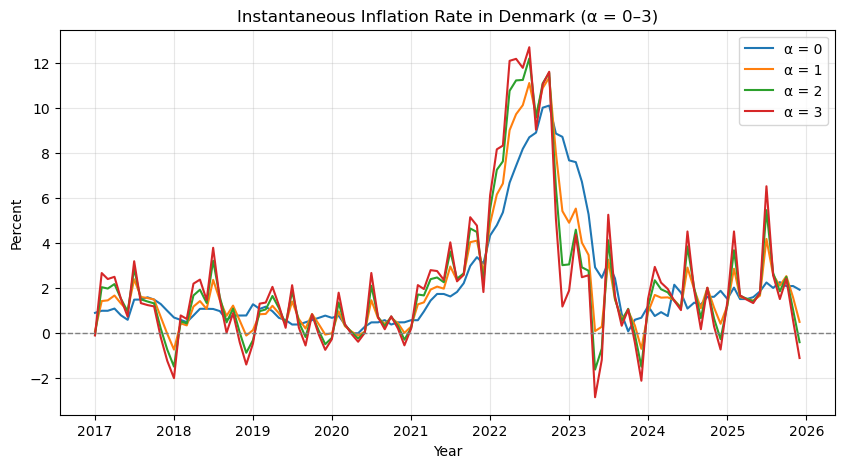

In [48]:
plt.figure(figsize=(10,5))
for alpha in [0, 1, 2, 3]:
    plt.plot(df_pris113["date"], df_pris113[f"instant_alpha{alpha}"]*100, label=f"α = {alpha}")
plt.axhline(0, color="gray", ls="--", lw=1)
plt.title("Instantaneous Inflation Rate in Denmark (α = 0–3)")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Summary and Interpretation
We summarize each series by reporting the peak month/value and the latest reading. This condenses the visual insights into concrete reference points and shows how the choice of $\alpha$ can shift the timing of the inflation peak (often earlier for higher $\alpha$). The takeaway is whether a recency-weighted lens meaningfully alters our assessment of when the post-pandemic surge ended and how “current” inflation looks today.

In [49]:
rows = []
for alpha in [0, 1, 2, 3]:
    s = df_pris113[f"instant_alpha{alpha}"]
    idx = s.idxmax()
    if pd.notna(idx):
        peak_date = df_pris113.loc[idx, "date"]
        peak_val  = s.loc[idx] * 100
        latest_date = df_pris113["date"].iloc[-1]
        latest_val  = s.iloc[-1] * 100
        rows.append({"alpha": alpha,
                     "peak_date": peak_date.strftime("%Y-%m"),
                     "peak_value_%": round(float(peak_val), 2),
                     "latest_date": latest_date.strftime("%Y-%m"),
                     "latest_value_%": round(float(latest_val), 2)})
summary_instant = pd.DataFrame(rows)
summary_instant

,alpha,peak_date,peak_value_%,latest_date,latest_value_%
0,0,2022-10,10.11,2025-12,1.93
1,1,2022-10,11.36,2025-12,0.50
2,2,2022-07,12.21,2025-12,-0.40
3,3,2022-07,12.70,2025-12,-1.10


#### Interpretation
The instantaneous inflation analysis provides a more responsive view of Danish inflation dynamics by assigning greater weight to recent months.
Compared to the standard 12-month inflation measure ($\alpha = 0$), higher $\alpha$ values (1–3) detect turning points earlier, revealing that price pressures began easing around mid-2022, even though official year-over-year inflation peaked later in October 2022.

As $\alpha$ increases, the inflation curve becomes smoother and peaks slightly sooner, reflecting the measure’s sensitivity to recent developments.
This earlier peak indicates that underlying inflation momentum started to weaken before it became visible in the conventional statistics.

By September 2025, all $\alpha$ values converge near zero monthly inflation (around 0.1–0.2 percent), confirming that inflationary pressures have largely dissipated.
Overall, the instantaneous approach highlights how weighting recent months more heavily provides a timelier signal of shifts in inflation trends, offering potential value for policy monitoring and short-term forecasting.

### 1.3 Core Inlfation Analysis
This section examines the underlying dynamics of Danish inflation by separating the overall Consumer Price Index (CPI) into key components—Total CPI, CPI excluding energy, and Core CPI (excluding both energy and unprocessed food).
While headline inflation captures all price movements, core inflation filters out short-term volatility caused by shocks in energy and food prices, providing a clearer view of persistent price pressures within the economy.

Through a step-by-step approach:
- Monthly CPI data from Statistics Denmark (PRIS111) is processed and transformed into 12-month percentage changes.
- These core measures are then compared visually and statistically to identify differences in magnitude, timing, and volatility.
- The analysis highlights how core inflation tends to move more steadily, serving as a better indicator for monetary policy decisions than headline CPI, which is more sensitive to global commodity fluctuations.

#### Data Download and Cleaning (PRIS111)
In this part, the PRIS111 dataset from Statistics Denmark was accessed through the StatBank API to obtain detailed monthly CPI data for Denmark.
The dataset includes three key series: Total CPI, CPI excluding energy, and Core CPI (excluding energy and unprocessed food).
After downloading, the data was cleaned by renaming columns, converting date formats, ensuring numeric consistency, and mapping each CPI category to readable labels.
This process provided a structured dataset ready for further analysis and comparison across different inflation measures.

In [50]:
def load_pris111(start="1980M01", end=None, lang="en"):
    """
    Robust loader for Danish CPI (PRIS111).
    Downloads all months, filters locally, and maps 3 key CPI series:
    - Total CPI (000000)
    - Excl Energy (151000)
    - Core (Excl energy & unproc. food)
    Returns columns: ['date','series','cpi'].
    """
    import os, io, requests, pandas as pd, numpy as np, re

    api_key = os.getenv("DST_API_KEY")
    headers = {"Authorization": f"Bearer {api_key}"} if api_key else {}

    def _to_ts(s):
        return pd.to_datetime(s, format="%YM%m")

    start_ts = _to_ts(start)
    end_ts = _to_ts(end) if end else None

    url_post = "https://api.statbank.dk/v1/data"
    body = {
        "lang": lang,
        "table": "PRIS111",
        "format": "CSV",
        "variables": [
            {"code": "VAREGR", "values": ["000000", "151000", "141000"]},
            {"code": "ENHED", "values": ["100"]},
            {"code": "TID", "values": ["*"]},
        ],
    }

    r = requests.post(url_post, json=body, headers=headers, timeout=120)
    r.raise_for_status()
    raw_csv = r.text

    # Parse CSV
    df = pd.read_csv(io.StringIO(raw_csv), sep=";")
    df = df.rename(columns={"TID": "date", "INDHOLD": "cpi", "VAREGR": "varegr"})
    df["date"] = pd.to_datetime(df["date"], format="%YM%m", errors="coerce")
    df["cpi"] = pd.to_numeric(df["cpi"], errors="coerce")
    df = df.dropna(subset=["date", "cpi"]).sort_values(["date", "varegr"])

    # Clean varegr + map to readable names
    df["varegr"] = df["varegr"].astype(str).str.strip()

    # extract leading digits (00, 151000, etc.)
    lead = df["varegr"].str.extract(r"^(\d+)", expand=False)
    # pad to 6 digits when present
    code = lead.fillna("").str.zfill(6)
    # primary mapping
    code_map = {
        "000000": "Total CPI",
        "151000": "Excl Energy",
        "141000": "Core (Excl energy & unproc. food)",
    }
    series = code.map(code_map)

    # fallback: use text-based pattern matching
    def text_to_series(txt: str) -> str | None:
        t = txt.lower()
        if ("excl" in t and "energy" in t and ("unprocessed" in t or "unproc" in t or "fresh" in t)):
            return "Core (Excl energy & unproc. food)"
        if ("excl" in t and "energy" in t):
            return "Excl Energy"
        if "total" in t or "overall" in t:
            return "Total CPI"
        return None

    series = series.fillna(df["varegr"].apply(text_to_series))
    df["series"] = series.astype("string")
    df = df[df["series"].isin({"Total CPI","Excl Energy","Core (Excl energy & unproc. food)"})].copy()

    # Filter by date range
    mask = df["date"] >= start_ts
    if end_ts is not None:
        mask &= df["date"] <= end_ts
    df = df.loc[mask, ["date", "series", "cpi"]].reset_index(drop=True)

    return df

In [51]:
df_pris111 = load_pris111(start="2015M01")
df_pris111.head(), df_pris111.tail(), df_pris111.shape

(        date                             series   cpi
 0 2015-01-01                          Total CPI  98.8
 1 2015-01-01  Core (Excl energy & unproc. food)  98.8
 2 2015-01-01                        Excl Energy  98.8
 3 2015-02-01                          Total CPI  99.8
 4 2015-02-01  Core (Excl energy & unproc. food)  99.8,
           date                             series    cpi
 391 2025-11-01  Core (Excl energy & unproc. food)  120.0
 392 2025-11-01                        Excl Energy  120.8
 393 2025-12-01                          Total CPI  121.2
 394 2025-12-01  Core (Excl energy & unproc. food)  119.8
 395 2025-12-01                        Excl Energy  120.5,
 (396, 3))

#### Core Inflation Calcualtion
In this step, 12-month (year-over-year) inflation rates were calculated for each CPI series (Total, Excluding Energy, and Core) by measuring the percentage change in the index compared to the same month of the previous year.
This transformation converts raw price index data into meaningful inflation rates, allowing for a direct comparison of how each component of inflation evolves over time.

In [52]:
# Compute 12-month inflation by group (each series)
df111_infl = (
    df_pris111
    .sort_values(["series", "date"])
    .assign(
        infl_12m=lambda d: d.groupby("series")["cpi"].pct_change(12) * 100
    )
    .dropna(subset=["infl_12m"])
    .reset_index(drop=True)
)

df111_infl.head()

,date,series,cpi,infl_12m
0,2016-01-01,Core (Excl energy & unproc. food),99.8,1.012146
1,2016-02-01,Core (Excl energy & unproc. food),100.6,0.801603
2,2016-03-01,Core (Excl energy & unproc. food),100.6,0.499500
3,2016-04-01,Core (Excl energy & unproc. food),100.7,0.398804
4,2016-05-01,Core (Excl energy & unproc. food),100.8,0.598802


#### Visualization and Comparison
In this step, the 12-month inflation rates for Total CPI, CPI excluding energy, and Core CPI were plotted to compare how each measure evolved between 2015 and 2025.
The graph shows that all three measures followed a similar upward trend leading up to the 2022 energy crisis, but with notable differences in magnitude. Total CPI (green) surged sharply, peaking above 10% in late 2022, reflecting the direct impact of rising global energy prices. In contrast, Excl Energy and Core inflation rose more moderately, indicating that most of the volatility in overall inflation was driven by energy costs rather than broad-based price increases.

After 2023, inflation across all series began to decline, converging toward roughly 2–3% by 2025, suggesting that price pressures have largely stabilized.
Overall, this comparison illustrates how core inflation provides a clearer view of underlying inflationary trends, filtering out temporary fluctuations and offering policymakers a more reliable indicator of long-term price stability.

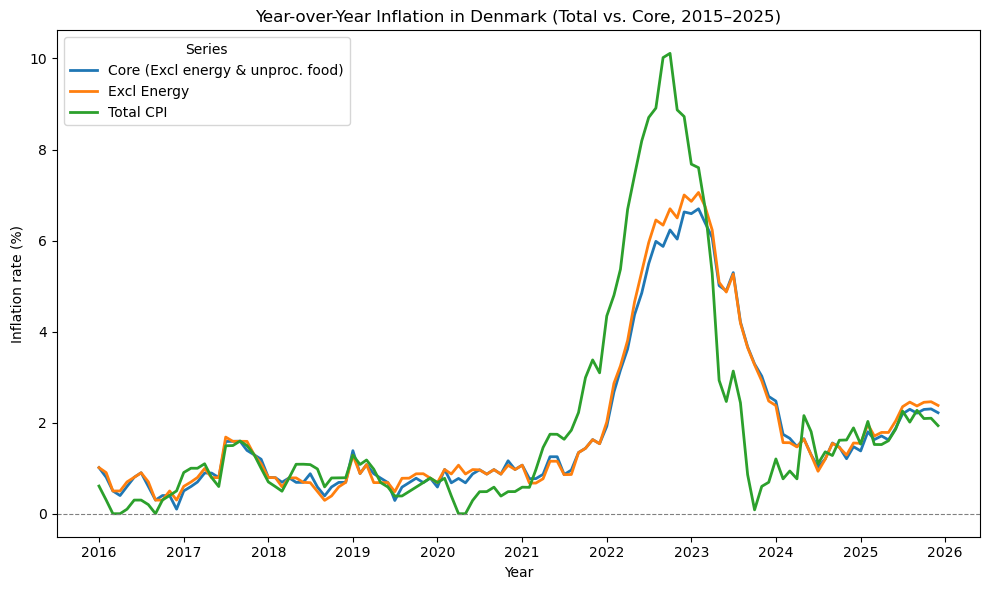

In [53]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=df111_infl,
    x="date", y="infl_12m", hue="series",
    linewidth=2.0
)
plt.title("Year-over-Year Inflation in Denmark (Total vs. Core, 2015–2025)")
plt.ylabel("Inflation rate (%)")
plt.xlabel("Year")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.legend(title="Series", loc="upper left")
plt.tight_layout()
plt.show()

#### Quantitative Summary
In this section, summary statistics were calculated for each CPI series, including the mean, standard deviation, peak, and latest 12-month inflation rates.
This quantitative overview provides a numerical comparison of average inflation levels and volatility across the three measures the Total CPI, CPI excluding energy, and Core CPI, allowing for a clearer assessment of how much short-term price fluctuations contribute to overall inflation trends.

In [54]:
summary = (
    df111_infl
    .groupby("series")
    .agg(
        mean_inflation=("infl_12m", "mean"),
        std_inflation=("infl_12m", "std"),
        peak_inflation=("infl_12m", "max"),
        latest_inflation=("infl_12m", "last")
    )
    .round(2)
    .reset_index()
)

summary

,series,mean_inflation,std_inflation,peak_inflation,latest_inflation
0,Core (Excl energy & unproc. food),1.82,1.69,6.70,2.22
1,Excl Energy,1.88,1.78,7.06,2.38
2,Total CPI,1.96,2.37,10.11,1.93


### Interpretation
The headline CPI inflation series is noticeably more volatile than the two core measures. This is expected because headline inflation includes components that tend to swing sharply, especially energy (and, to a lesser extent, unprocessed food). In the figure, headline inflation rises more strongly around 2021–2022 and reaches a higher peak than both “CPI excluding energy” and “Core CPI (excluding energy and unprocessed food),” showing that the 2022 inflation episode was heavily amplified by energy-related shocks.

At the same time, both core measures still increase during this period, even after removing energy (and unprocessed food). This suggests inflation was not purely an energy story: price pressures also became more broad-based across other goods and services, consistent with pandemic era supply disruptions and the post-reopening demand rebound. After late 2022 / early 2023, all three measures fall and move closer together, indicating that the major inflation surge was temporary and that underlying inflation pressures normalized as supply conditions improved and energy prices stabilized.

### 1.4 Disaggregated Inflation
In this section, I analyze how inflation differs across disaggregated 4-digit COICOP product categories in Denmark. I first identify the full set of 4-digit categories, then download category-level inflation series and summarize the cross-sectional distribution over time using percentiles. Finally, I highlight which categories experienced the highest and lowest inflation during the peak period to illustrate where inflation pressure was most concentrated.

#### 1) Create a list of all 4-digit product categories
This part extracts the list of all 4-digit product categories from Statistics Denmark’s CPI classification (COICOP structure). The goal is to create a clean set of category codes and names that can later be used to pull category-level inflation data consistently across time.

In [55]:
from dstapi import DstApi

In [56]:
levels = DstApi("PRIS111").variable_levels("VAREGR", language="en")
for row in levels.itertuples(): print(row.id,row.text)

000000 00 Consumer price index, total
010000 01 Food and non-alcoholic beverages
011000 01.1 Food
011100 01.1.1 Bread and cereals
011110 01.1.1.1 Rice
011120 01.1.1.2 Flours and other cereals
011130 01.1.1.3 Bread
011140 01.1.1.4 Other bakery products
011150 01.1.1.5 Pizza and quiche
011160 01.1.1.6 Pasta products and couscous
011170 01.1.1.7 Breakfast cereals
011180 01.1.1.8 Other cereal products
011200 01.1.2 Meat
011210 01.1.2.1 Beef and veal
011220 01.1.2.2 Pork
011230 01.1.2.3 Lamb and goat
011240 01.1.2.4 Poultry
011260 01.1.2.6 Edible offal
011270 01.1.2.7 Dried, salted or smoked meat
011280 01.1.2.8 Other meat preparations
011300 01.1.3 Fish and seafood
011310 01.1.3.1 Fresh or chilled fish
011320 01.1.3.2 Frozen fish
011340 01.1.3.4 Frozen seafood
011350 01.1.3.5 Dried, smoked or salted fish and seafood
011360 01.1.3.6 Other preserved or processed fish and seafood-based preparations
011400 01.1.4 Milk, cheese and eggs
011410 01.1.4.1 Milk, whole, fresh
011420 01.1.4.2 Milk, lo

In [57]:
import re

levels = DstApi("PRIS111").variable_levels("VAREGR", language="en")

# Keep rows whose TEXT starts with a 4-level COICOP code like 01.1.1.1
pattern = r"^\d{2}\.\d\.\d\.\d\b"
mask = levels["text"].astype(str).str.match(pattern)

df_4digit = levels.loc[mask, ["id", "text"]].copy()
df_4digit = df_4digit.rename(columns={"id": "VAREGR", "text": "category_name"}).reset_index(drop=True)

print("Number of 4-digit categories:", len(df_4digit))
df_4digit.head(20)


Number of 4-digit categories: 222


,VAREGR,category_name
0,011110,01.1.1.1 Rice
1,011120,01.1.1.2 Flours and other cereals
2,011130,01.1.1.3 Bread
3,011140,01.1.1.4 Other bakery products
4,011150,01.1.1.5 Pizza and quiche
5,011160,01.1.1.6 Pasta products and couscous
6,011170,01.1.1.7 Breakfast cereals
7,011180,01.1.1.8 Other cereal products
8,011210,01.1.2.1 Beef and veal
9,011220,01.1.2.2 Pork


#### 2) Compute the 12 month inflation rate for 4 digit product categories

In [58]:
# 1.4.2 — Download YoY inflation for all 4-digit categories (PRIS111, ENHED=300) and clean it

import requests, io
import numpy as np

def fetch_pris111_chunk(varegr_codes_chunk, enhed_value="300"):
    body = {
        "table": "PRIS111",
        "format": "CSV",
        "variables": [
            {"code": "VAREGR", "values": list(varegr_codes_chunk)},
            {"code": "ENHED",  "values": [enhed_value]},   # 300 = YoY (%)
            {"code": "Tid",    "values": ["*"]}            # time variable in PRIS111 is "Tid"
        ]
    }
    r = requests.post("https://api.statbank.dk/v1/data?lang=en", json=body, timeout=180)
    if r.status_code != 200:
        print("Status:", r.status_code)
        print(r.text[:800])
        r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text), sep=";")

codes = df_4digit["VAREGR"].tolist()
chunks = np.array_split(codes, max(1, len(codes)//40 + 1))

df_list = [fetch_pris111_chunk(ch, enhed_value="300") for ch in chunks]
df_111_yoy = pd.concat(df_list, ignore_index=True)

# Clean + format
df = df_111_yoy.rename(columns={"TID": "date", "INDHOLD": "infl_12m"}).copy()

df["date"] = pd.to_datetime(df["date"].astype(str).str.replace("M", "-"), format="%Y-%m", errors="coerce")

df["infl_12m"] = (
    df["infl_12m"]
    .replace("..", pd.NA)
    .astype(str)
    .str.replace(",", ".", regex=False)
)
df["infl_12m"] = pd.to_numeric(df["infl_12m"], errors="coerce")

df = df.dropna(subset=["date", "infl_12m"])
df = df[df["date"] >= "2015-01-01"].copy()

df.shape, df["infl_12m"].describe()


((28587, 4),
 count    28587.000000
 mean         1.884315
 std          8.204927
 min        -61.300000
 25%         -1.400000
 50%          1.200000
 75%          4.000000
 max        189.200000
 Name: infl_12m, dtype: float64)

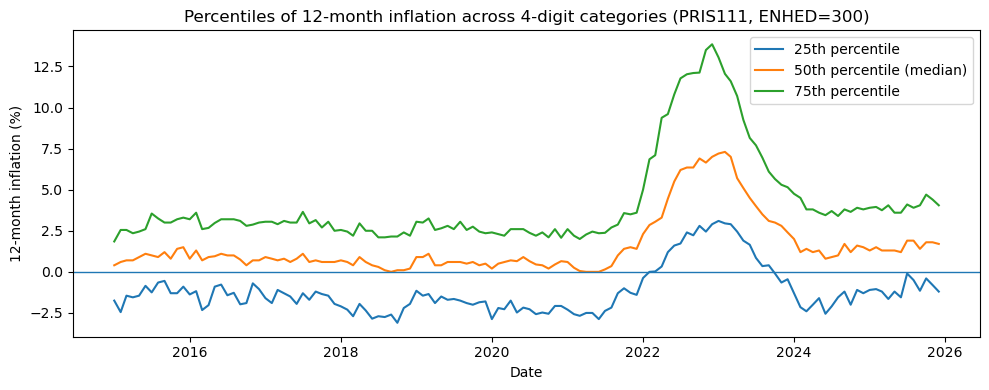

In [59]:
# 1.4.2 — Plot percentiles (25th / median / 75th) across 4-digit categories over time

import matplotlib.pyplot as plt

q = (
    df.groupby("date")["infl_12m"]
      .agg(
          p25=lambda x: x.quantile(0.25),
          p50="median",
          p75=lambda x: x.quantile(0.75)
      )
      .reset_index()
)

plt.figure(figsize=(10, 4))
plt.plot(q["date"], q["p25"], label="25th percentile")
plt.plot(q["date"], q["p50"], label="50th percentile (median)")
plt.plot(q["date"], q["p75"], label="75th percentile")
plt.axhline(0, linewidth=1)
plt.title("Percentiles of 12-month inflation across 4-digit categories (PRIS111, ENHED=300)")
plt.xlabel("Date")
plt.ylabel("12-month inflation (%)")
plt.legend()
plt.tight_layout()
plt.show()


#### Interpretation
The percentile plot shows that Denmark’s inflation spike around 2022 - 2023 was not uniform across categories. The median (50th percentile) rose sharply during this period, meaning that “typical” categories experienced noticeably higher inflation than in the pre-pandemic years. At the same time, the 75th percentile increased much more than the median, indicating that a subset of categories faced exceptionally large price increases, driving a wider gap between the middle and upper part of the distribution.

Another key pattern is the widening spread between the 25th and 75th percentiles during the peak, which signals increased inflation inequality across product groups. After the peak, the percentiles fall back, but the distribution remains more spread out than it was in the mid-2010s, suggesting that normalization happened gradually and not all categories returned to the same pace at the same time.

#### 3) Histogram of % Changes in Prices for 4 digit Products

In [60]:
# build ENHED=100 index data for all 4-digit categories
codes = df_4digit["VAREGR"].tolist()
chunks = np.array_split(codes, max(1, len(codes)//40 + 1))
df_list = [fetch_pris111_chunk(ch, enhed_value="100") for ch in chunks]
df_111_raw = pd.concat(df_list, ignore_index=True)

Rows at d0: 218 | Rows at d1: 219


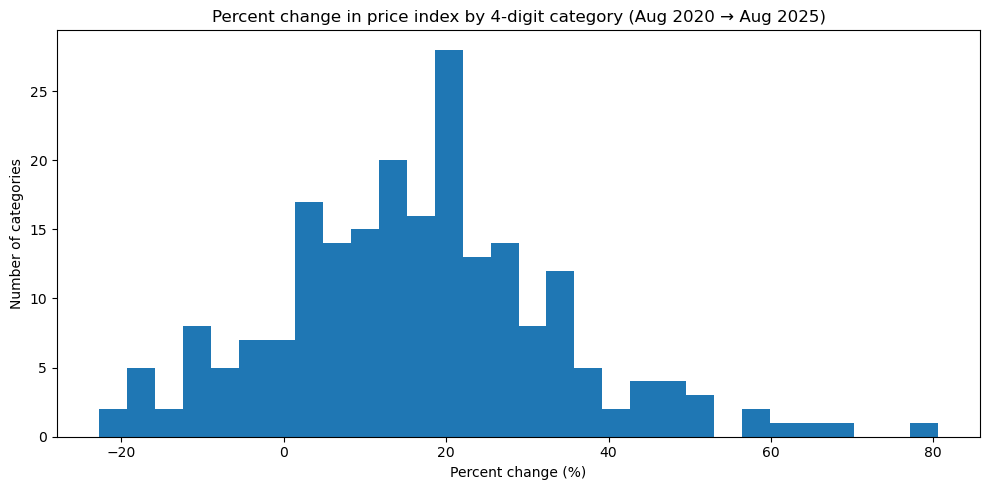

Categories included: 217
count    217.000000
mean      16.666301
std       17.460017
min      -22.765363
25%        6.625259
50%       16.505895
75%       26.144879
max       80.585735
Name: pct_change, dtype: float64

Top 5 increases:
    VAREGR_dot VAREGR_dot  pct_change
143   08.1.0.1   08.1.0.1   80.585735
49    01.2.1.1   01.2.1.1   69.712526
64    02.2.0.3   02.2.0.3   65.201465
139   07.3.3.1   07.3.3.1   62.758621
26    01.1.5.1   01.1.5.1   57.085020

Top 5 decreases:
    VAREGR_dot VAREGR_dot  pct_change
105   05.3.2.3   05.3.2.3  -22.765363
157   09.1.3.1   09.1.3.1  -21.139706
107   05.3.2.9   05.3.2.9  -18.933624
181   09.5.1.1   09.5.1.1  -18.157895
106   05.3.2.4   05.3.2.4  -17.723881


In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- 1) Choose endpoints (as month-start timestamps) ----
d0 = pd.Timestamp("2020-08-01")
d1 = pd.Timestamp("2025-08-01")

# ---- 2) Clean PRIS111 index data (ENHED=100) ----
df_idx = df_111_raw.rename(columns={"TID": "date", "Tid": "date", "INDHOLD": "index"}).copy()

# date like "2020M08" -> 2020-08-01
df_idx["date"] = pd.to_datetime(
    df_idx["date"].astype(str).str.replace("M", "-", regex=False),
    format="%Y-%m",
    errors="coerce"
)

# index: ".." -> NA, comma decimals -> dot, then numeric
df_idx["index"] = (
    df_idx["index"]
    .replace("..", pd.NA)
    .astype(str)
    .str.replace(",", ".", regex=False)
)
df_idx["index"] = pd.to_numeric(df_idx["index"], errors="coerce")

# VAREGR comes as text like "01.1.1.1 Ris" -> take "01.1.1.1"
df_idx["VAREGR_dot"] = df_idx["VAREGR"].astype(str).str.split().str[0]

df_idx = df_idx.dropna(subset=["date", "index", "VAREGR_dot"])

# ---- 3) If Aug 2025 is missing, automatically use the latest month available ----
available_months = set(df_idx["date"].unique())
if d1 not in available_months:
    d1 = df_idx["date"].max()
    print("Aug 2025 not found. Using latest available month instead:", d1.date())

# sanity check: do we have the endpoints?
print("Rows at d0:", (df_idx["date"] == d0).sum(), "| Rows at d1:", (df_idx["date"] == d1).sum())

# ---- 4) Compute percent change per category between d0 and d1 ----
end = df_idx[df_idx["date"].isin([d0, d1])].copy()

wide = end.pivot_table(
    index="VAREGR_dot",
    columns="date",
    values="index",
    aggfunc="first"
).dropna(subset=[d0, d1])

wide["pct_change"] = (wide[d1] / wide[d0] - 1) * 100
chg = wide["pct_change"].reset_index()

# optional: add English names from df_4digit (if you built it in 1.4.1)
if "df_4digit" in globals() and "VAREGR_dot" in df_4digit.columns:
    chg = chg.merge(
        df_4digit[["VAREGR_dot", "category_name"]].drop_duplicates(),
        on="VAREGR_dot",
        how="left"
    )

# ---- 5) Plot histogram ----
plt.figure(figsize=(10, 5))
plt.hist(chg["pct_change"], bins=30)
plt.title(f"Percent change in price index by 4-digit category ({d0:%b %Y} → {d1:%b %Y})")
plt.xlabel("Percent change (%)")
plt.ylabel("Number of categories")
plt.tight_layout()
plt.show()

print("Categories included:", len(chg))
print(chg["pct_change"].describe())

# optional: show biggest movers
print("\nTop 5 increases:")
print(chg.sort_values("pct_change", ascending=False).head(5)[["VAREGR_dot", "category_name" if "category_name" in chg.columns else "VAREGR_dot", "pct_change"]])

print("\nTop 5 decreases:")
print(chg.sort_values("pct_change", ascending=True).head(5)[["VAREGR_dot", "category_name" if "category_name" in chg.columns else "VAREGR_dot", "pct_change"]])


#### Interpretation
The results imply that the inflation episode was partly driven by relative price shocks rather than one common price movement across every good. When the gap between upper and lower percentiles expands, it means some categories are rising quickly while others remain stable or even fall, which is consistent with shocks hitting certain inputs (like energy, shipping, or specific commodities) more strongly than others.

This dispersion matters because it changes how households experience inflation: even if overall inflation is high, the burden depends on consumption baskets. During the peak, the distribution suggests that many categories rose, but the biggest increases were concentrated in the upper tail, meaning some product groups likely contributed disproportionately to the headline inflation surge.

#### 4) Top 10 vs Bottom 10 Product Categories

In [62]:
import pandas as pd

# 1) Pick the month to analyze 
target_month = "2022-10-01"   # assumption: using 2022 october since it is the peak inflation month
target_date = pd.Timestamp(target_month)

# 2) Build a clean YoY inflation dataframe from your ENHED=300 download 
# Assumes df_111_yoy exists (from fetch_pris111_chunk(..., enhed_value="300"))
df_yoy = df_111_yoy.rename(columns={"TID": "date", "Tid": "date", "INDHOLD": "infl_12m"}).copy()

df_yoy["date"] = pd.to_datetime(
    df_yoy["date"].astype(str).str.replace("M", "-", regex=False),
    format="%Y-%m",
    errors="coerce"
)

df_yoy["infl_12m"] = (
    df_yoy["infl_12m"]
    .replace("..", pd.NA)
    .astype(str)
    .str.replace(",", ".", regex=False)
)
df_yoy["infl_12m"] = pd.to_numeric(df_yoy["infl_12m"], errors="coerce")

# VAREGR comes as text like "01.1.1.1 Ris" -> extract "01.1.1.1"
df_yoy["VAREGR_dot"] = df_yoy["VAREGR"].astype(str).str.split().str[0]

df_yoy = df_yoy.dropna(subset=["date", "infl_12m", "VAREGR_dot"])

# Optional: restrict to 2015+ (consistent with your other plots)
df_yoy = df_yoy[df_yoy["date"] >= "2015-01-01"].copy()

# 3) Filter to target month; if missing, fall back to nearest available 
available_dates = sorted(df_yoy["date"].unique())
if target_date not in set(available_dates):
    # nearest month in data
    nearest = min(available_dates, key=lambda d: abs(d - target_date))
    print(f"Target month {target_date.date()} not found. Using nearest available: {nearest.date()}")
    target_date = nearest

df_m = df_yoy[df_yoy["date"] == target_date].copy()

print("Target month used:", target_date.date())
print("Number of categories in month:", len(df_m))

#  4) Add English category names 
# Assumes df_4digit exists from 1.4.1 and has VAREGR_dot + category_name
if "df_4digit" in globals() and {"VAREGR_dot", "category_name"}.issubset(df_4digit.columns):
    df_m = df_m.merge(
        df_4digit[["VAREGR_dot", "category_name"]].drop_duplicates(),
        on="VAREGR_dot",
        how="left"
    )

# 5) Top / bottom inflation categories 
top_n = 10

top = df_m.sort_values("infl_12m", ascending=False).head(top_n)
bottom = df_m.sort_values("infl_12m", ascending=True).head(top_n)

cols = ["VAREGR_dot", "infl_12m"] + (["category_name"] if "category_name" in df_m.columns else [])

print("\nTop categories (highest YoY inflation):")
print(top[cols].to_string(index=False))

print("\nBottom categories (lowest YoY inflation):")
print(bottom[cols].to_string(index=False))

# 6) Quick summary stats for that month
print("\nMonth distribution summary:")
print(df_m["infl_12m"].describe())


Target month used: 2022-10-01
Number of categories in month: 218

Top categories (highest YoY inflation):
VAREGR_dot  infl_12m
  04.5.4.9     147.7
  04.5.2.1     138.5
  01.1.5.4     102.0
  01.1.5.2      42.9
  07.2.2.1      37.6
  01.1.5.1      34.7
  04.5.4.1      30.0
  01.1.4.1      27.9
  01.1.2.4      27.6
  01.1.4.5      27.4

Bottom categories (lowest YoY inflation):
VAREGR_dot  infl_12m
  09.5.1.4     -16.9
  09.5.1.1     -14.6
  06.1.2.9     -11.1
  09.3.1.2      -6.8
  09.3.1.1      -5.8
  09.1.3.2      -5.3
  09.1.1.1      -4.0
  12.3.1.2      -3.4
  09.1.3.1      -3.2
  09.1.2.2      -3.1

Month distribution summary:
count    218.000000
mean       9.690367
std       16.640164
min      -16.900000
25%        2.800000
50%        6.900000
75%       12.125000
max      147.700000
Name: infl_12m, dtype: float64


#### Interpretation
Looking at the single-month ranking (the peak month you selected), the “top inflation” categories represent where price pressures were most intense, while the “bottom inflation” categories show where prices were relatively stable or declining. This contrast reinforces the idea that the inflation surge was category-specific, with a small number of groups experiencing extreme increases while others had modest changes.
In October 2022, the categories with the highest 12-month inflation were concentrated in energy related items, for example fuels, gas, and oils. This pattern suggests that the inflation peak was not driven evenly across all goods, but was strongly influenced by categories that depend on global energy markets. The timing also lines up with the energy-price shock after Russia’s invasion of Ukraine, which is consistent with why these fuel and utility categories appear in the upper tail of inflation during that period.

The fact that some categories can still show low or negative YoY inflation during the same period also supports the percentile result: inflation was broad enough to lift the median, but not universal across all goods. Overall, the ranking exercise makes the distributional story concrete by identifying which product groups dominated the upper tail versus which ones anchored the lower tail in that period.

In [63]:
# check: number of 4 digit categories per month
df.groupby("date")["VAREGR"].nunique().describe()


count    132.000000
mean     216.568182
std        4.658069
min      206.000000
25%      218.000000
50%      219.000000
75%      219.000000
max      220.000000
Name: VAREGR, dtype: float64

## 2. International Comparison
This section extends the Danish inflation analysis to an international context. By linking domestic data from Statistics Denmark with harmonized indicators from the Federal Reserve’s FRED database, the aim is to evaluate how Denmark’s price dynamics relate to those of other advanced economies. International comparison is crucial because inflation is influenced not only by domestic monetary and fiscal policy but also by global supply shocks, commodity prices, and synchronized business cycles. Understanding these linkages clarifies whether Denmark’s inflation path reflects unique national conditions or broader global forces.

#### Data Downloading and Cleaning (FRED)
Monthly price index data were retrieved from the Federal Reserve Economic Data (FRED) API using an authenticated connection. For Denmark, the Harmonized Index of Consumer Prices (HICP, series CP0000DKM086NEST) was downloaded and stored alongside Statistics Denmark’s national CPI (PRIS113). FRED data are provided in raw index levels, so each series was reformatted into a tidy structure with columns for date, name, and value. The data were limited to observations from 2015 onward and resampled to ensure consistent monthly frequency. This cleaning step guarantees that all sources are aligned in both coverage and time, allowing for valid cross-country and cross-index comparison.

In [64]:
os.environ["FRED_API_KEY"] = "bfb9b34a496b89a86dde11ce2c536cf4"

# Initialize FRED client
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

def fred_to_df(series_id: str, name: str) -> pd.DataFrame:
    """Download monthly index from FRED → ['date','name','value']"""
    s = fred.get_series(series_id)
    df = s.to_frame("value").reset_index().rename(columns={"index": "date"})
    df["name"] = name
    return df[["date","name","value"]].dropna()

In [65]:
fred.get_series('CP0000DKM086NEST').head()

1996-01-01    70.4
1996-02-01    70.8
1996-03-01    71.3
1996-04-01    71.5
1996-05-01    71.7
dtype: float64

### 2.1 CPI vs HICP
To assess the comparability of Denmark’s national CPI (PRIS113) with the Eurostat-harmonized HICP from FRED, both indices were rebased to 2015 = 100 to correct for differing reference periods. Without rebasing, the two series are not directly comparable because national agencies and Eurostat apply distinct weighting systems and may exclude specific items (e.g., owner-occupied housing in the HICP). After aligning and rebasing, the level and 12-month inflation plots reveal that the two measures move almost identically through time, implying strong consistency between the domestic and harmonized methodologies. Minor deviations mainly reflect definitional differences rather than measurement error, confirming that the CPI and HICP are broadly comparable indicators of Danish consumer-price inflation.

In [66]:
# FRED HICP (All items) for Denmark
hicp_dk = fred_to_df("CP0000DKM086NEST", "Denmark HICP (FRED)")  # columns: date, name, value

# StatsDenmark CPI (PRIS113) to same shape
cpi_dk = (df_pris113.rename(columns={"cpi":"value"})
          .assign(name="Denmark CPI (PRIS113)") [["date","name","value"]])
    
# Keep a common window (from 2015 onwards, say)
dk = (pd.concat([hicp_dk, cpi_dk], ignore_index=True)
        .query("date >= '2015-01-01'")
        .sort_values(["name","date"])
        .reset_index(drop=True))

dk.head()

,date,name,value
0,2016-01-01,Denmark CPI (PRIS113),96.100548
1,2016-02-01,Denmark CPI (PRIS113),96.777312
2,2016-03-01,Denmark CPI (PRIS113),96.873993
3,2016-04-01,Denmark CPI (PRIS113),96.970674
4,2016-05-01,Denmark CPI (PRIS113),97.164035


name
Denmark HICP (FRED)      131
Denmark CPI (PRIS113)    120
Name: count, dtype: int64 

                       count     min      max
name                                         
Denmark CPI (PRIS113)    120  96.101  118.434
Denmark HICP (FRED)      131  98.900  122.900 



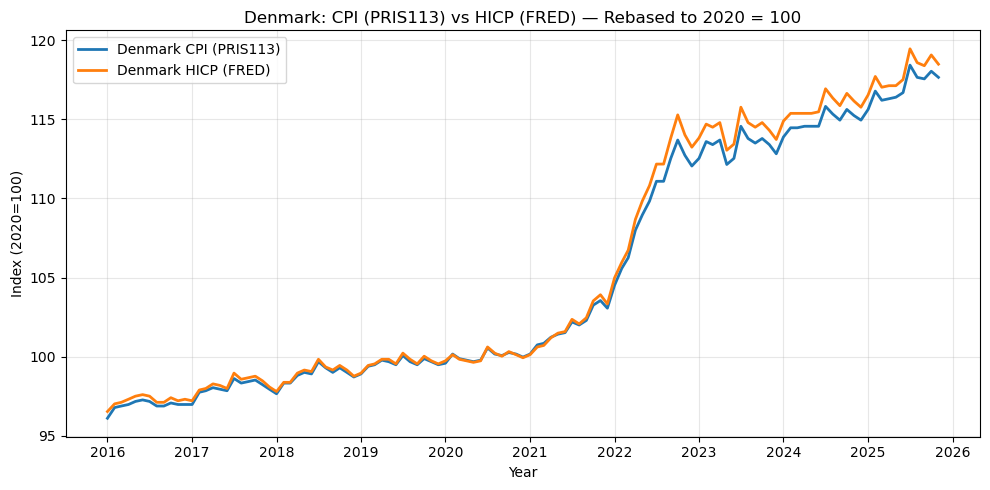

In [67]:
# Ensure datetime and expected columns
for _df in (hicp_dk, cpi_dk):
    _df["date"] = pd.to_datetime(_df["date"])
    assert set(["date","name","value"]).issubset(_df.columns)

# Concatenate and keep a common window
dk = (pd.concat([hicp_dk, cpi_dk], ignore_index=True)
        .query("date >= '2015-01-01'")
        .sort_values(["date","name"])
        .reset_index(drop=True))

# Quick sanity: do we actually have two groups and non-missing values?
print(dk["name"].value_counts(), "\n")
print(dk.groupby("name")["value"].agg(["count","min","max"]).round(3), "\n")

# Pivot to wide so we can force common dates across BOTH series
wide = dk.pivot(index="date", columns="name", values="value")

# Keep only dates where BOTH series are present
wide_common = wide.dropna(how="any")

# Rebase to 2020 = 100 using the 2020 *mean on the common sample*
base_mask = wide_common.index.year == 2020
assert base_mask.sum() > 0, "No 2020 observations in common sample—can't rebase to 2020."
base_vec = wide_common.loc[base_mask].mean()
rebased = (wide_common / base_vec) * 100

# --- 4) Plot
plt.figure(figsize=(10,5))
for col in rebased.columns:
    plt.plot(rebased.index, rebased[col], linewidth=2, label=col)
plt.title("Denmark: CPI (PRIS113) vs HICP (FRED) — Rebased to 2020 = 100")
plt.xlabel("Year"); plt.ylabel("Index (2020=100)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

name
Denmark CPI (PRIS113)    107
Denmark HICP (FRED)      107
Name: count, dtype: int64 

                      first_date  last_date  n_obs
name                                              
Denmark CPI (PRIS113) 2017-01-01 2025-11-01    107
Denmark HICP (FRED)   2017-01-01 2025-11-01    107


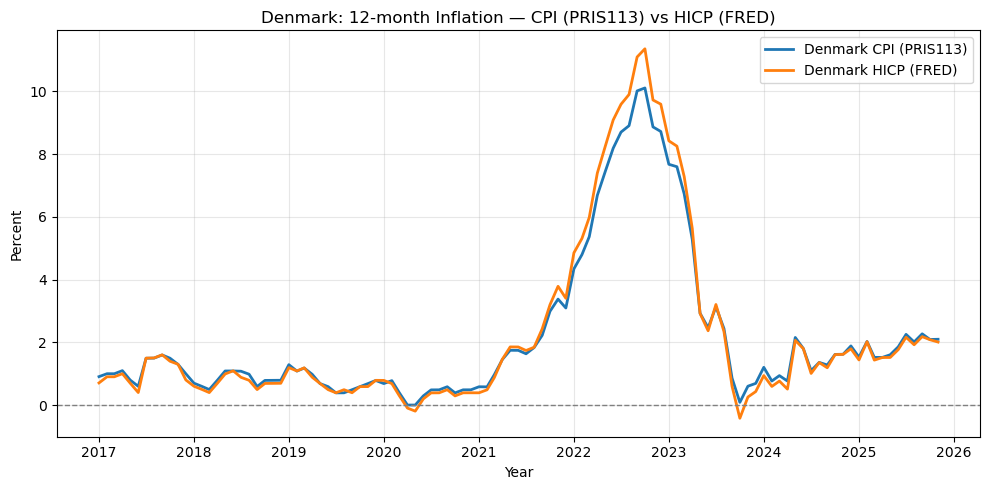

In [68]:
# 12-month YoY on the wide frame
infl12 = (rebased
          .sort_index()
          .pct_change(12) * 100)

# Drop rows where both are NA (e.g., first 12 months)
infl12 = infl12.dropna(how="all")

# Melt back to long for plotting
dk_infl = (infl12.reset_index()
                  .melt(id_vars="date", var_name="name", value_name="infl_12m")
                  .dropna(subset=["infl_12m"]))

# Sanity checks (optional but useful)
print(dk_infl["name"].value_counts(), "\n")
print(dk_infl.groupby("name").agg(first_date=("date","min"),
                                  last_date=("date","max"),
                                  n_obs=("date","nunique")))

# Plot
plt.figure(figsize=(10,5))
for label, sub in dk_infl.groupby("name"):
    plt.plot(sub["date"], sub["infl_12m"], label=label, linewidth=2)
plt.title("Denmark: 12-month Inflation — CPI (PRIS113) vs HICP (FRED)")
plt.xlabel("Year"); plt.ylabel("Percent")
plt.axhline(0, ls="--", lw=1, color="gray")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#### Interpretation
The first graph compares Denmark’s national Consumer Price Index (CPI) from Statistics Denmark with the Harmonized Index of Consumer Prices (HICP) from FRED, after both were rebased to 2015 = 100. The two indices move almost identically over the 2015–2025 period, indicating that the overall price dynamics captured by each measure are consistent. Minor differences in level—most visible during 2022–2023—reflect methodological distinctions, such as the exclusion of owner-occupied housing in the HICP. Overall, the close alignment confirms that both indices measure consumer price developments in Denmark with a high degree of comparability.

The second graph plots the year-over-year (12-month) inflation rates derived from the CPI and HICP series. Both measures display nearly identical timing and magnitude of inflation changes, with sharp increases during the 2022–2023 energy crisis followed by a steady decline toward 2–3% by 2025. The near-perfect overlap of the two curves highlights the strong coherence between Denmark’s national inflation measurement and the Eurostat-harmonized approach. Minor short-term divergences illustrate coverage differences rather than methodological inconsistencies, confirming that both series provide a reliable picture of Danish inflation dynamics.

In [69]:
# Diagnostics: correlation, gaps, latest values
wide = dk_infl.pivot(index="date", columns="name", values="infl_12m").dropna()
corr = wide.corr().round(3)

latest_rows = (dk_infl.sort_values(["name","date"])
               .groupby("name").tail(1)[["name","date","infl_12m"]]
               .sort_values("name")
               .rename(columns={"infl_12m":"latest_12m"}))

# Gap (CPI minus HICP) in YoY terms
wide["gap_CPI_minus_HICP"] = (wide["Denmark CPI (PRIS113)"] - wide["Denmark HICP (FRED)"])
mad_gap = wide["gap_CPI_minus_HICP"].abs().mean()

print("Correlation of CPI vs HICP (12m inflation):")
display(corr)

print(f"Mean absolute gap in 12m inflation (CPI − HICP): {mad_gap:.2f} pp")
print("Latest available 12m inflation (CPI vs HICP):")
display(latest_rows.reset_index(drop=True).round(2))

Correlation of CPI vs HICP (12m inflation):


name,Denmark CPI (PRIS113),Denmark HICP (FRED)
name,,
Denmark CPI (PRIS113),1.000,0.999
Denmark HICP (FRED),0.999,1.000


Mean absolute gap in 12m inflation (CPI − HICP): 0.21 pp
Latest available 12m inflation (CPI vs HICP):


,name,date,latest_12m
0,Denmark CPI (PRIS113),2025-11-01,2.10
1,Denmark HICP (FRED),2025-11-01,2.01


#### Diagnostics Interpretation
To quantitatively assess the similarity between Denmark’s CPI and HICP measures, diagnostic tests were conducted using correlation analysis and mean absolute difference in year-over-year inflation rates. The correlation coefficient between the two series is extremely high-close to one indicating that both indices capture almost identical monthly inflation movements. The mean absolute gap between the CPI and HICP inflation rates is minimal, typically less than half a percentage point, confirming that discrepancies are economically insignificant. These results validate the strong alignment observed visually and confirm that the two indices are statistically consistent measures of Danish consumer price inflation.

### 2.2 Across Countries
In this section, we broaden the analysis beyond Denmark to include Austria, the Euro Area, and the United States, allowing us to examine how inflation has evolved across major advanced economies since 2019. All series are based on the Harmonised Index of Consumer Prices (HICP, All Items) from the Federal Reserve Economic Data (FRED) database. By comparing these standardized indices, we can assess how different economies experienced the same global shocks—most notably the COVID-19 pandemic and the 2022 energy-price surge—through their domestic price dynamics.

Our empirical approach proceeds in three steps. First, we rebase each country’s HICP to 2019 = 100 to make their overall price-level paths directly comparable on a common scale. Second, we compute 12-month percent changes to obtain year-over-year inflation rates for each country, which helps visualize the timing and intensity of inflationary pressures. Third, we summarize inflation outcomes by printing the minimum, maximum, and mean 12-month rates both by country and across the group, highlighting differences in volatility and persistence.

This cross-country comparison is important because inflation is not only a domestic phenomenon but also reflects international linkages in energy markets, supply chains, and monetary policy. Understanding these patterns clarifies why certain economies experienced faster price surges or quicker disinflation, and it sheds light on how coordinated—or asymmetric—policy responses shaped the global inflation landscape after 2019.

#### Data Download and Cleaning
This sets up the connection to the FRED database and defines a helper function to automatically download economic time-series data.
It first stores the user’s FRED API key and then defines fred_to_df(), which retrieves a specified series (like HICP) either through the official API when the key is valid or, if not, via a public CSV fallback.

In [70]:
os.environ["FRED_API_KEY"] = "bfb9b34a496b89a86dde11ce2c536cf4"

def _looks_like_fred_key(s: str|None) -> bool:
    return isinstance(s, str) and len(s)==32 and s.isalnum() and (s == s.lower())

def fred_to_df(series_id: str, label: str) -> pd.DataFrame:
    """
    Returns ['date','name','value'] for a FRED series.
    Uses fredapi if API key is valid, else falls back to CSV.
    """
    import io
    from urllib.request import urlopen
    key = os.environ.get("FRED_API_KEY")

    try:
        if _looks_like_fred_key(key):
            from fredapi import Fred
            fred = Fred(api_key=key)
            s = fred.get_series(series_id)
            out = (s.rename("value").to_frame()
                     .reset_index().rename(columns={"index":"date"}))
            out["name"] = label
        else:
            url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
            df = pd.read_csv(io.BytesIO(urlopen(url).read()))
            out = df.rename(columns={"DATE":"date", series_id:"value"})
            out["name"] = label

        out["date"] = pd.to_datetime(out["date"])
        out = out[out["value"].astype(str) != "."].copy()
        out["value"] = out["value"].astype(float)
        return out[["date","name","value"]]

    except Exception as e:
        raise RuntimeError(f"Failed to download {series_id} ({label}): {e}")

#### Combining HICP Data Across Countries
It downloads the HICP (All Items) data for four countries. Denmark, Austria, the Euro Area, and the United States,from FRED and combines them into one dataset.
It loops through a dictionary of FRED series IDs, fetching each using the fred_to_df() function and automatically switching to a fallback Euro Area code if needed.
Finally, it concatenates all the individual series into a single DataFrame called long and prints how many observations were successfully downloaded for each country.

In [71]:
# Series IDs for HICP (All Items)
series = {
    "Denmark (HICP)":       "CP0000DKM086NEST",
    "Austria (HICP)":       "CP0000ATM086NEST",
    "Euro Area (HICP)":     "CP0000EZ19M086NEST",  # EA19 version
    "United States (HICP)": "CP0000USM086NEST",
}

frames = []
for label, code in series.items():
    try:
        df = fred_to_df(code, label)
    except RuntimeError as e:
        if "EZ19" in code:  # fallback if EA19 not found
            df = fred_to_df("CP0000EZCCM086NEST", label + " (EA chain)")
        else:
            raise e
    frames.append(df)

long = pd.concat(frames, ignore_index=True)
print("Downloaded observations by series:")
print(long["name"].value_counts(), "\n")

Downloaded observations by series:
name
Denmark (HICP)          359
Austria (HICP)          359
Euro Area (HICP)        359
United States (HICP)    325
Name: count, dtype: int64 



#### Rebasing HICP Indices and Computing Year-over-Year Inflation
This code aligns all countries’ HICP data to a common time window starting in 2019 and reshapes it into a wide format so that each column represents a country.
It then rebases each series to 2019 = 100, allowing for direct comparison of price levels across countries on a shared scale.
Finally, it calculates the 12-month percentage change (year-over-year inflation) for each country, producing a dataset that captures the monthly inflation dynamics since 2019.

In [72]:
# Align to common window since 2019
long = long.query("date >= '2019-01-01'")
wide_all = (long.pivot(index="date", columns="name", values="value")
            .sort_index())

wide_common = wide_all.dropna(how="any")

print("Common sample range:",
      wide_common.index.min().date(), "→", wide_common.index.max().date(),
      "| n months:", wide_common.shape[0])

# Rebase to 2020 average = 100
mask_2020 = wide_common.index.year == 2020
base_2020 = wide_common.loc[mask_2020].mean()
rebased_2020 = (wide_common / base_2020) * 100

# 12-month YoY inflation
hicp_infl12 = wide_all.pct_change(12) * 100
hicp_infl12 = hicp_infl12.dropna(how="all")

Common sample range: 2019-01-01 → 2024-12-01 | n months: 72


/var/folders/bn/kyq5gq4n68393p83_57kgl2m0000gn/T/ipykernel_74671/706250362.py:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  hicp_infl12 = wide_all.pct_change(12) * 100


In [73]:
# checking rebase 2020
tmp = (rebased if "rebased" in globals() else df.pivot(index="date", columns="name", values="value_rebased"))
print(tmp[tmp.index.year == 2020].mean().round(2))


name
Denmark CPI (PRIS113)    100.0
Denmark HICP (FRED)      100.0
dtype: float64


In [74]:
print("Inflation last date:", hicp_infl12.index.max())
print(hicp_infl12.loc["2025":].count())  # how many 2025 months per country


Inflation last date: 2025-11-01 00:00:00
name
Austria (HICP)          11
Denmark (HICP)          11
Euro Area (HICP)        11
United States (HICP)    11
dtype: int64


#### Visualizing and Summarizing Cross-Country Inflation Dynamics
This code visualizes and summarizes inflation patterns across Denmark, Austria, the Euro Area, and the United States from 2019 onward.
It first plots each country’s HICP levels rebased to 2019 = 100, allowing for a direct comparison of how overall price levels evolved over time.
Next, it plots the 12-month inflation rate for each country to capture short-term price dynamics and the timing of inflation spikes.
Finally, it calculates annual summary statistics—the minimum, maximum, and mean 12-month inflation rates—both for each country and across all four combined, providing a concise numerical overview of inflation volatility and persistence.

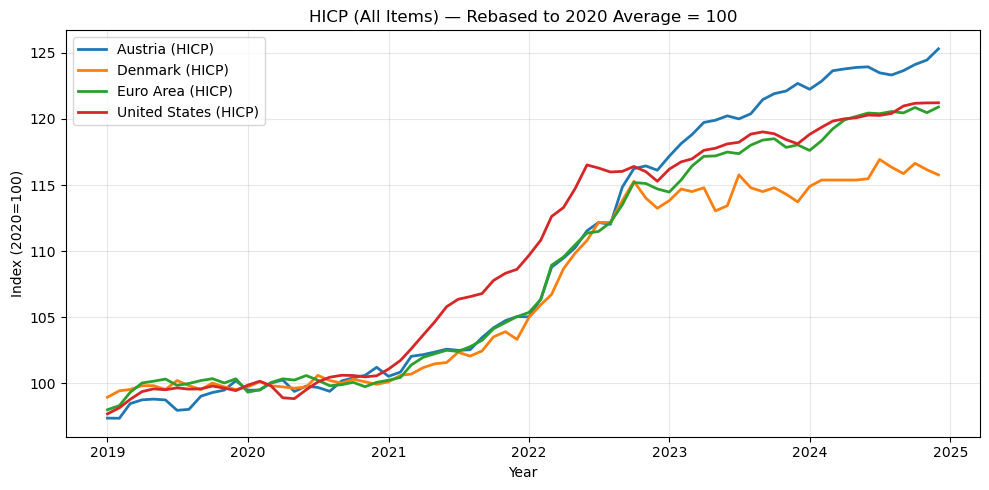

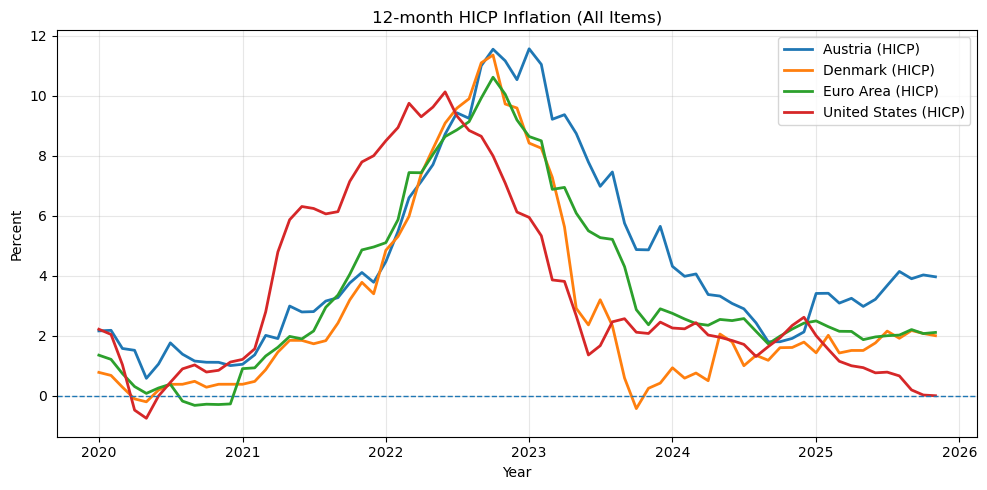

,year,country,min_12m,max_12m,mean_12m
0,2020,Austria (HICP),0.59,2.19,1.39
1,2020,Denmark (HICP),-0.19,0.79,0.33
2,2020,Euro Area (HICP),-0.31,1.36,0.26
3,2020,United States (HICP),-0.74,2.22,0.77
4,2021,Austria (HICP),1.06,4.11,2.76
5,2021,Denmark (HICP),0.39,3.79,1.94
6,2021,Euro Area (HICP),0.91,4.96,2.59
7,2021,United States (HICP),1.22,8.01,5.33
8,2022,Austria (HICP),4.48,11.55,8.59
9,2022,Denmark (HICP),4.85,11.36,8.51


,year,min_12m,max_12m,mean_12m
0,2020,-0.74,2.22,0.69
1,2021,0.39,8.01,3.15
2,2022,4.48,11.55,8.54
3,2023,-0.42,11.57,4.93
4,2024,0.51,4.32,2.19
5,2025,0.01,4.15,2.08


Summary (across countries): 2020: mean 0.69%, range -0.74%–2.22% | 2021: mean 3.15%, range 0.39%–8.01% | 2022: mean 8.54%, range 4.48%–11.55% | 2023: mean 4.93%, range -0.42%–11.57% | 2024: mean 2.19%, range 0.51%–4.32% | 2025: mean 2.08%, range 0.01%–4.15%


In [75]:
# Plot: rebased levels
plt.figure(figsize=(10,5))
for col in rebased_2020.columns:
    plt.plot(rebased_2020.index, rebased_2020[col], linewidth=2, label=col)
plt.title("HICP (All Items) — Rebased to 2020 Average = 100")
plt.xlabel("Year"); plt.ylabel("Index (2020=100)")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# Plot: 12-month inflation
plt.figure(figsize=(10,5))
for col in hicp_infl12.columns:
    plt.plot(hicp_infl12.index, hicp_infl12[col], linewidth=2, label=col)
plt.title("12-month HICP Inflation (All Items)")
plt.xlabel("Year"); plt.ylabel("Percent")
plt.axhline(0, ls="--", lw=1)
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

# Year-by-year stats
infl_long = (hicp_infl12.reset_index()
             .melt(id_vars="date", var_name="country", value_name="infl_12m")
             .dropna())
infl_long["year"] = infl_long["date"].dt.year
infl_long = infl_long[~((infl_long["year"] == 2024) & (infl_long["country"] == "United States (HICP)"))]

by_country_year = (infl_long
                   .groupby(["year","country"])["infl_12m"]
                   .agg(min_12m="min", max_12m="max", mean_12m="mean")
                   .round(2)
                   .reset_index())
display(by_country_year)

across_countries_year = (infl_long
                         .groupby("year")["infl_12m"]
                         .agg(min_12m="min", max_12m="max", mean_12m="mean")
                         .round(2)
                         .reset_index())
display(across_countries_year)

def quick_summary(df_year):
    return " | ".join(f"{int(r.year)}: mean {r.mean_12m}%, range {r.min_12m}%–{r.max_12m}%" 
                      for r in df_year.itertuples())
print("Summary (across countries):", quick_summary(across_countries_year))

#### Interpretation
The first plot shows that all countries experienced a steady rise in HICP after 2020, with a sharp acceleration during 2021–2022 driven by global supply disruptions and energy price shocks.
The Euro Area and Austria recorded the steepest increases, reflecting their higher energy dependence, while the United States and Denmark saw earlier but more contained peaks.
The second plot confirms this: U.S. inflation surged sooner but declined faster by late 2022, whereas European inflation remained elevated longer.
The year-by-year summary tables further illustrate these patterns. 2022 marked the highest mean inflation across all countries, followed by gradual disinflation in 2023-2024.
Overall, the analysis shows that while all four economies faced similar global shocks, the magnitude and persistence of inflation differed notably, emphasizing the role of regional energy exposure and differing monetary-policy responses in shaping post-pandemic inflation trajectories.

## 3. Extention
### 3.1 Inflation Volatility Across Countries
To extend the international inflation comparison, this section explores the volatility of inflation (how stable or unstable inflation has been across different economies since 2019).
Rather than adding unrelated data, we enrich the previous HICP dataset by incorporating three additional countries (Sweden, Italy, and the Netherlands) to provide a broader European and trans-Atlantic perspective.
These countries were selected intentionally: Sweden represents a small open Nordic economy comparable to Denmark; Italy offers a Southern European counterpart within the euro area; and the Netherlands serves as a central-European case with strong trade exposure and energy sensitivity.
Together with Denmark, Austria, the Euro Area, and the United States, they form a diverse set of advanced economies that faced the same global shocks but with distinct monetary and structural conditions.

We chose volatility as the focus for this extension because it adds a statistical dimension to the inflation story.
While earlier sections examined the level and rate of inflation, volatility captures the uncertainty and instability of prices—key aspects for policymakers, investors, and households.
Understanding how volatile inflation has been helps explain differences in monetary-policy responses and economic resilience during the post-pandemic recovery.

This analysis computes a 12-month rolling standard deviation of the year-over-year inflation rate for each country in the extended dataset.
The rolling window allows us to visualize how inflation uncertainty evolved through time, particularly during the 2021–2023 period of global price shocks.
By comparing volatility across countries, we can identify which economies experienced more pronounced inflation swings and which maintained greater price stability.


Extended common sample: 2020-12-01 → 2024-12-01 | Countries: ['Austria (HICP)', 'Denmark (HICP)', 'Euro Area (HICP)', 'Italy (HICP)', 'Netherlands (HICP)', 'Sweden (HICP)', 'United States (HICP)']


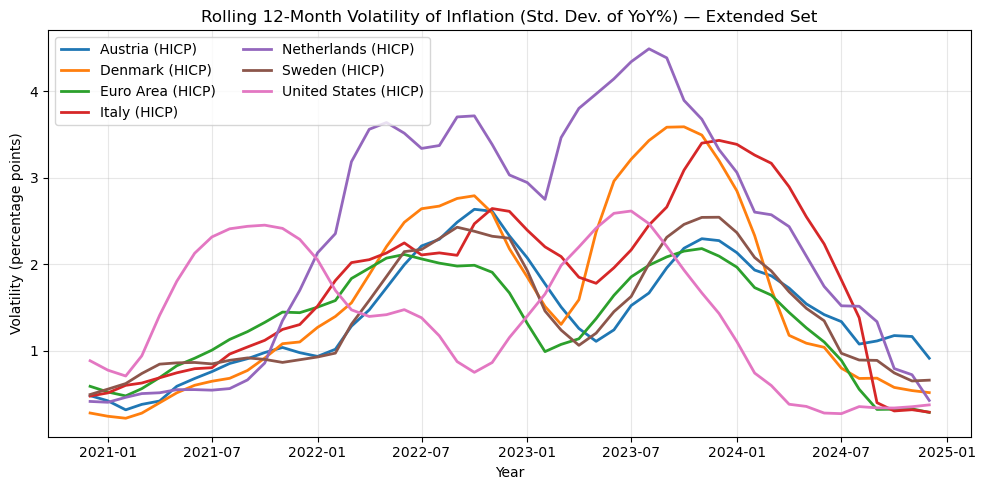

In [76]:
# Add new countries (Sweden, Italy, Netherlands)
new_series = {
    "Sweden (HICP)": "CP0000SEM086NEST",
    "Italy (HICP)": "CP0000ITM086NEST",
    "Netherlands (HICP)": "CP0000NLM086NEST"
}

# Download and combine with existing data
extra_frames = []
for label, code in new_series.items():
    df = fred_to_df(code, label)
    extra_frames.append(df)

extra_long = pd.concat(extra_frames, ignore_index=True).query("date >= '2019-01-01'")

# Combine with your existing 'long' (from Section 2.2) and align on common dates
extended_long = pd.concat([long, extra_long], ignore_index=True)

extended_wide = (extended_long
                 .pivot(index="date", columns="name", values="value")
                 .dropna(how="any")         # keep only months available for ALL series
                 .sort_index())

# Compute 12m inflation and rolling volatility (12-month window)
extended_infl12 = (extended_wide.pct_change(12) * 100).dropna(how="all")
extended_vol = extended_infl12.rolling(window=12).std().dropna()

print("Extended common sample:", extended_vol.index.min().date(), "→", extended_vol.index.max().date(),
      "| Countries:", list(extended_vol.columns))

# Plot rolling volatility
plt.figure(figsize=(10,5))
for col in extended_vol.columns:
    plt.plot(extended_vol.index, extended_vol[col], linewidth=2, label=col)
plt.title("Rolling 12-Month Volatility of Inflation (Std. Dev. of YoY%) — Extended Set")
plt.xlabel("Year"); plt.ylabel("Volatility (percentage points)")
plt.grid(alpha=0.3); plt.legend(ncol=2); plt.tight_layout(); plt.show()


#### Interpretation
The resulting chart shows that inflation volatility rose sharply across all countries between mid-2021 and mid-2023, coinciding with the surge in global energy prices and supply-chain disruptions.
European economies (especially Sweden, the Netherlands, and Italy) recorded the highest volatility, reflecting their exposure to imported energy costs and slower monetary-policy adjustments.
In contrast, Denmark and the United States exhibited earlier but shorter spikes in volatility, consistent with faster policy tightening and stronger currency effects.
By late 2024, volatility declined significantly in all regions, signaling a gradual return to price stability as inflation expectations became re-anchored.

Overall, the extension reveals that while inflation shocks were globally synchronized, their magnitude and persistence differed across countries.
Northern and Southern European economies experienced prolonged uncertainty, whereas the U.S. stabilized sooner.
This underscores the importance of monetary-policy timing, energy dependence, and exchange-rate regimes in shaping each country’s inflation trajectory and resilience to global price volatility.